In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import pickle
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

In [2]:
# 2. Load Dataset
books = pd.read_csv("./input/book-recommendation-dataset/Books.csv")
ratings = pd.read_csv("./input/book-recommendation-dataset/Ratings.csv")

books.shape, ratings.shape

C:\Users\User\AppData\Local\Temp\ipykernel_6836\1438750432.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("./input/book-recommendation-dataset/Books.csv")


((271360, 8), (1149780, 3))

In [3]:
# 3. Preprocess Data
filtered_data = books[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']].dropna()


In [4]:
# 4. TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(
    filtered_data['Book-Title'] + " " +
    filtered_data['Book-Author'] + " " +
    filtered_data['Publisher'] + " " +
    filtered_data['Year-Of-Publication'].astype(str)
)
tfidf_matrix.shape

(271356, 116789)

In [5]:
# 5. Dimensionality Reduction using SVD
svd = TruncatedSVD(n_components=120, random_state=42)
book_embeddings = svd.fit_transform(tfidf_matrix)
book_embeddings.shape

(271356, 120)

In [6]:
# 6. Train-Test Split (70% Train, 30% Test)
train_ratings, test_ratings = train_test_split(ratings, test_size=0.30, random_state=42)
test_ratings

,User-ID,ISBN,Book-Rating
178554,38781,0373259131,0
533905,128835,0811805905,8
1091374,261829,037324486X,0
1036247,247747,0531303306,0
309523,74076,0316812404,0
...,...,...,...
654843,158559,0385486073,7
1010576,242361,1400031885,8
669719,162738,0425140032,0
86620,18401,0451410831,10


In [7]:
# 7. Train KNN Model on the training set
knn = NearestNeighbors(n_neighbors=20, metric='euclidean')

# Ensure the indices are aligned by resetting index of filtered_data
filtered_data = filtered_data.reset_index(drop=True)

# Use only the books in the training set for KNN
train_books = filtered_data[filtered_data['ISBN'].isin(train_ratings['ISBN'])]

# Get the corresponding embeddings for the training set
train_embeddings = book_embeddings[train_books.index]

# Fit the KNN model on the training embeddings
knn.fit(train_embeddings)


NearestNeighbors(metric='euclidean', n_neighbors=20)

In [8]:
# 8. Save Trained Models
with open('Trainedmodel/hybrid_models.pkl', 'wb') as f:
    pickle.dump({'vectorizer': vectorizer, 'svd': svd, 'knn': knn}, f)

In [9]:
# 9. Recommend Function
def recommend_books_with_ratings(book_title, alpha=0.5):
    matches = filtered_data[filtered_data['Book-Title'].str.contains(book_title, case=False, na=False)]
    if matches.empty:
        return None, None, None

    closest_book = matches.iloc[0]
    book_index = filtered_data.index[filtered_data['Book-Title'] == closest_book['Book-Title']].tolist()
    if not book_index:
        return None, None, None
    book_index = book_index[0]

    distances, indices = knn.kneighbors([book_embeddings[book_index]], n_neighbors=min(20, len(filtered_data)))

    recommended_books = [closest_book['Book-Title']]
    predicted_ratings = [5]

    for j in range(1, len(indices[0])):  # Skip the first book itself
        i = indices[0][j]
        if i >= len(filtered_data):
            continue

        rec_book = filtered_data.iloc[i]
        if rec_book['Book-Title'] in recommended_books:
            continue

        # exclude_keywords = ["Audio", "CD", "Music", "Postcard", "Method", "Guide", "Manual", "Pop-Up", "Nonpareil"]
        # if any(keyword in rec_book['Book-Title'] for keyword in exclude_keywords):
        #     continue

        content_similarity_score = 1 / (1 + distances[0][j])
        isbn_list = books[books['Book-Title'] == rec_book['Book-Title']]['ISBN']
        book_ratings = ratings[ratings['ISBN'].isin(isbn_list)]['Book-Rating']
        collaborative_rating = book_ratings.mean() if len(book_ratings) > 0 else 3

        hybrid_score = alpha * content_similarity_score * 5 + (1 - alpha) * collaborative_rating
        recommended_books.append(rec_book['Book-Title'])
        predicted_ratings.append(hybrid_score)

        if len(recommended_books) >= 10:
            break

    return closest_book, recommended_books, predicted_ratings

In [10]:
# 10. Evaluation Function
def get_actual_ratings(recommended_books):
    actual_ratings = []
    for book_title in recommended_books:
        isbn_list = books[books['Book-Title'] == book_title]['ISBN']
        book_ratings = ratings[ratings['ISBN'].isin(isbn_list)]['Book-Rating']
        if len(book_ratings) >= 10:
            actual_ratings.append(book_ratings.mean())
        else:
            actual_ratings.append(None)
    return actual_ratings

def evaluate_model(book_title):
    closest_book, recommended_books, predicted_ratings = recommend_books_with_ratings(book_title)
    actual_ratings = get_actual_ratings(recommended_books)
    valid_ratings = [(p, a) for p, a in zip(predicted_ratings, actual_ratings) if a is not None]

    if not valid_ratings:
        return closest_book, recommended_books, None, None, None, None

    predicted_ratings, actual_ratings = zip(*valid_ratings)
    mse = mean_squared_error(actual_ratings, predicted_ratings)
    rmse = np.sqrt(mse)

    threshold = 3
    y_true = [1 if rating >= threshold else 0 for rating in actual_ratings]
    y_pred = [1 if rating >= threshold else 0 for rating in predicted_ratings]

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return closest_book, recommended_books, rmse, precision, recall, f1

# 11. Test the Model on a Book
book_input = "Harry Potter and the Chamber of Secrets"
closest_book, recommendations, rmse, precision, recall, f1 = evaluate_model(book_input)

# Display Results
print(f"\n📖 Closest Match: {closest_book['Book-Title']} by {closest_book['Book-Author']}\n")
print("🔍 Recommended Books:")
for title in recommendations:
    print(f"- {title}")

if rmse:
    print(f"\n📊 Evaluation Metrics:")
    print(f"RMSE: {rmse:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
else:
    print("⚠️ Not enough data to evaluate performance.")


📖 Closest Match: Harry Potter and the Chamber of Secrets (Book 2) by J. K. Rowling

🔍 Recommended Books:
- Harry Potter and the Chamber of Secrets (Book 2)
- Ten Great Mysteries by Edgar Allan Poe
- Candide (Penguin Classics)
- Divine Secrets of the Ya-Ya Sisterhood: A Novel
- Servant of the Bones
- Doing Business on the Internet: How the Electronic Highway is Transforming American Companies
- Complete Guide to Finance and Accounting
- While Canada Slept: How We Lost Our Place in the World
- Seven Plays
- La divina comedia

📊 Evaluation Metrics:
RMSE: 0.6528
Precision: 0.8000
Recall: 1.0000
F1-Score: 0.8889


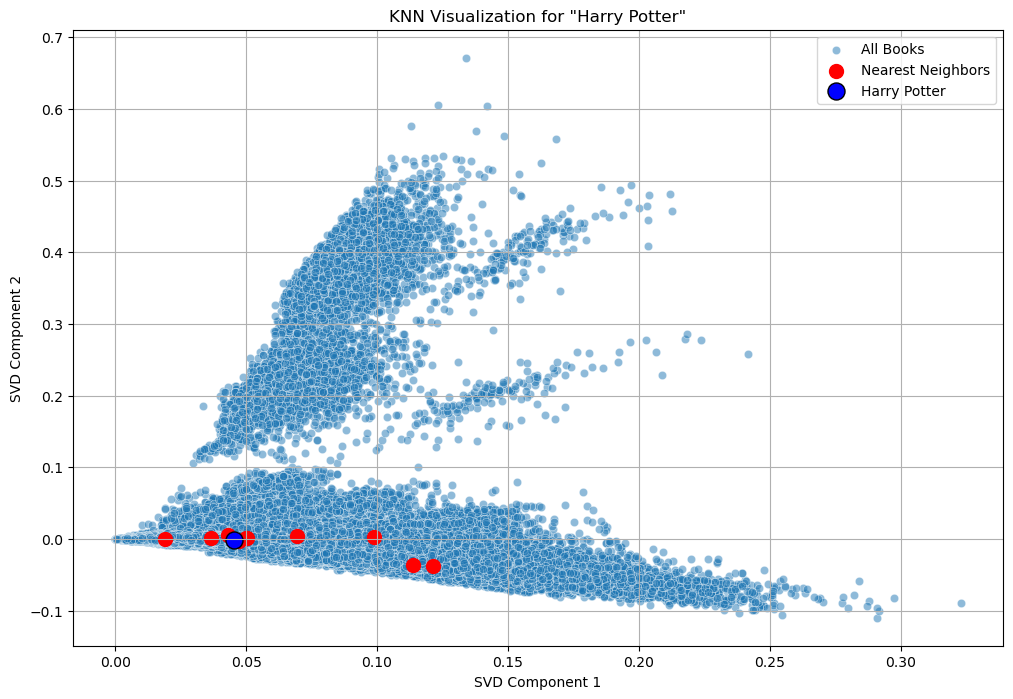

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Project embeddings to 2D for visualization
svd_2d = TruncatedSVD(n_components=2, random_state=42)
book_embeddings_2d = svd_2d.fit_transform(tfidf_matrix)

# Get index for Harry Potter
book_title = "Harry Potter"
matches = filtered_data[filtered_data['Book-Title'].str.contains(book_title, case=False, na=False)]

if not matches.empty:
    harry_index = matches.index[0]
    distances, indices = knn.kneighbors([book_embeddings[harry_index]], n_neighbors=10)

    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x=book_embeddings_2d[:, 0],
        y=book_embeddings_2d[:, 1],
        label='All Books',
        alpha=0.5
    )

    # Highlight nearest neighbors
    neighbor_points = book_embeddings_2d[indices[0]]
    plt.scatter(
        neighbor_points[:, 0],
        neighbor_points[:, 1],
        color='red',
        label='Nearest Neighbors',
        s=100
    )

    # Highlight input book
    plt.scatter(
        book_embeddings_2d[harry_index, 0],
        book_embeddings_2d[harry_index, 1],
        color='blue',
        label='Harry Potter',
        s=150,
        edgecolors='black'
    )

    plt.title('KNN Visualization for "Harry Potter"')
    plt.xlabel('SVD Component 1')
    plt.ylabel('SVD Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("❌ 'Harry Potter' not found in the dataset.")


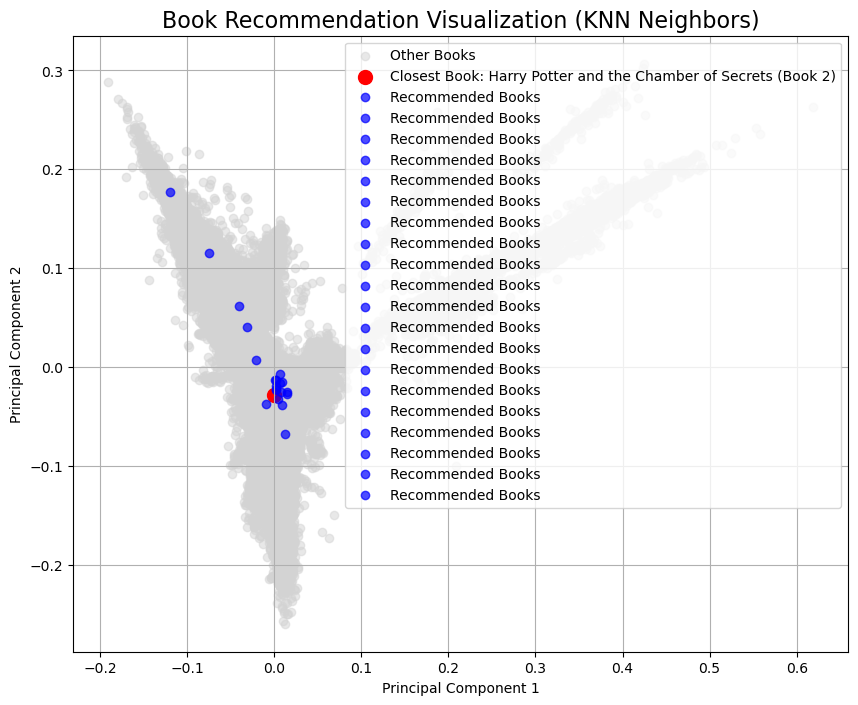

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Dimensionality Reduction to 2D (using PCA for simplicity)
pca = PCA(n_components=2)
book_embeddings_2d = pca.fit_transform(book_embeddings)

# Get the nearest neighbors for a sample book (e.g., "Harry Potter and the Chamber of Secrets")
book_title = "Harry Potter and the Chamber of Secrets"
matches = filtered_data[filtered_data['Book-Title'].str.contains(book_title, case=False, na=False)]
closest_book = matches.iloc[0]
book_index = filtered_data.index[filtered_data['Book-Title'] == closest_book['Book-Title']].tolist()[0]

# Find nearest neighbors
distances, indices = knn.kneighbors([book_embeddings[book_index]], n_neighbors=20)

# Plotting
plt.figure(figsize=(10, 8))

# Plot all book embeddings
plt.scatter(book_embeddings_2d[:, 0], book_embeddings_2d[:, 1], c='lightgray', label='Other Books', alpha=0.5)

# Plot the closest book
plt.scatter(book_embeddings_2d[book_index, 0], book_embeddings_2d[book_index, 1], c='red', label=f"Closest Book: {closest_book['Book-Title']}", s=100)

# Plot the nearest neighbors
for idx in indices[0]:
    plt.scatter(book_embeddings_2d[idx, 0], book_embeddings_2d[idx, 1], c='blue', label='Recommended Books', alpha=0.7)

# Labeling and aesthetics
plt.title("Book Recommendation Visualization (KNN Neighbors)", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(loc='upper right')
plt.grid(True)

# Show the plot
plt.show()
